In [1]:
import pandas as pd 

df = pd.read_csv('./data/texas_2025_game_log.csv')

## 타선, 불펜 순서 

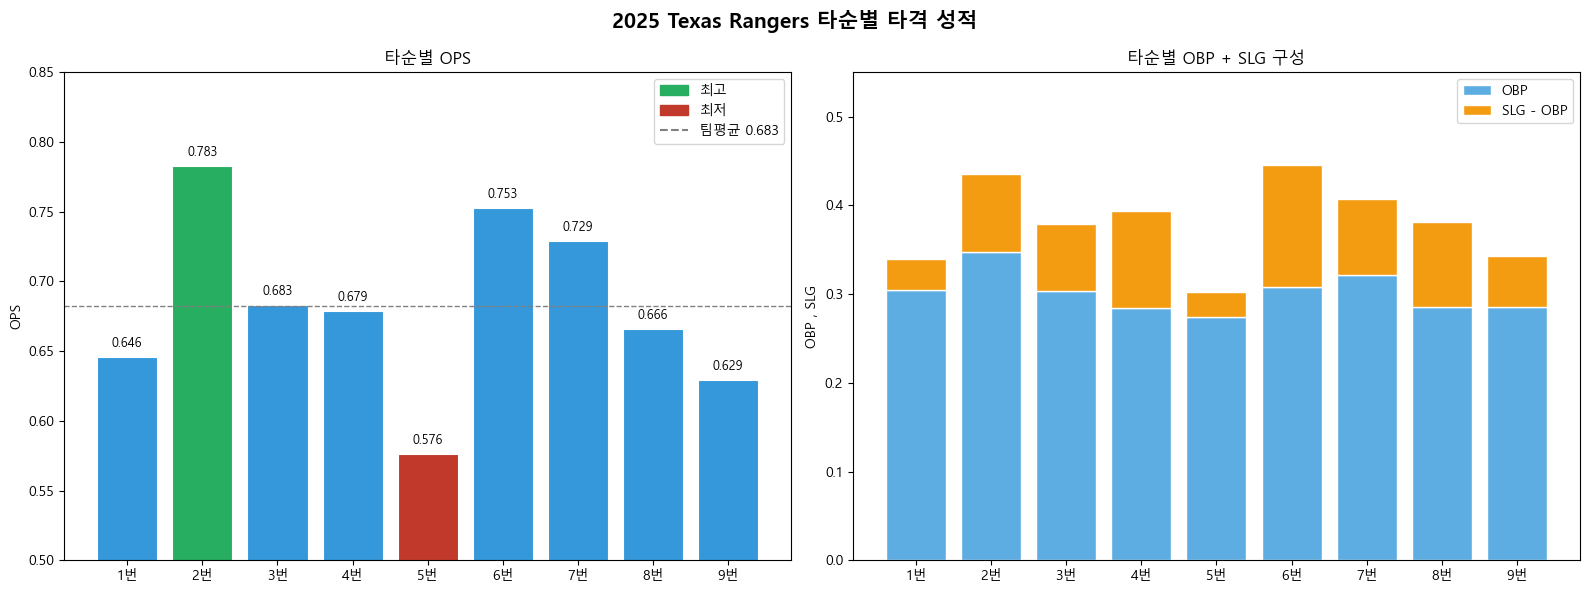

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import platform


# 운영체제별 한글 폰트 설정
if platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
    
df = pd.read_csv('./data/tex_2025_batting_order_splits.csv')
df = df[df['Split'].str.startswith('Batting')].copy()
df['order'] = range(1, 10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('2025 Texas Rangers 타순별 타격 성적', fontsize=15, fontweight='bold')

# --- 1) OPS 바 차트 ---
ax1 = axes[0]
colors = ['#C0392B' if v == df['OPS'].min() else
          '#27AE60' if v == df['OPS'].max() else
          '#3498DB' for v in df['OPS']]
bars = ax1.bar(df['order'], df['OPS'], color=colors, edgecolor='white', linewidth=0.8)
ax1.axhline(df['OPS'].mean(), color='gray', linestyle='--', linewidth=1)
for bar, val in zip(bars, df['OPS']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax1.set_xticks(df['order'])
ax1.set_xticklabels([f'{i}번' for i in df['order']])
ax1.set_ylabel('OPS')
ax1.set_title('타순별 OPS')
ax1.set_ylim(0.5, 0.85)
ax1.legend(handles=[
    mpatches.Patch(color='#27AE60', label='최고'),
    mpatches.Patch(color='#C0392B', label='최저'),
    plt.Line2D([0],[0], color='gray', linestyle='--', label=f'팀평균 {df["OPS"].mean():.3f}')
])

# --- 2) OBP / SLG 스택 바 ---
ax2 = axes[1]
ax2.bar(df['order'], df['OBP'], label='OBP', color='#5DADE2', edgecolor='white')
ax2.bar(df['order'], df['SLG'] - df['OBP'], bottom=df['OBP'], label='SLG - OBP', color='#F39C12', edgecolor='white')
ax2.set_xticks(df['order'])
ax2.set_xticklabels([f'{i}번' for i in df['order']])
ax2.set_ylabel('OBP , SLG')
ax2.set_title('타순별 OBP + SLG 구성')
ax2.set_ylim(0, 0.55)
ax2.legend()

plt.tight_layout()
plt.show()


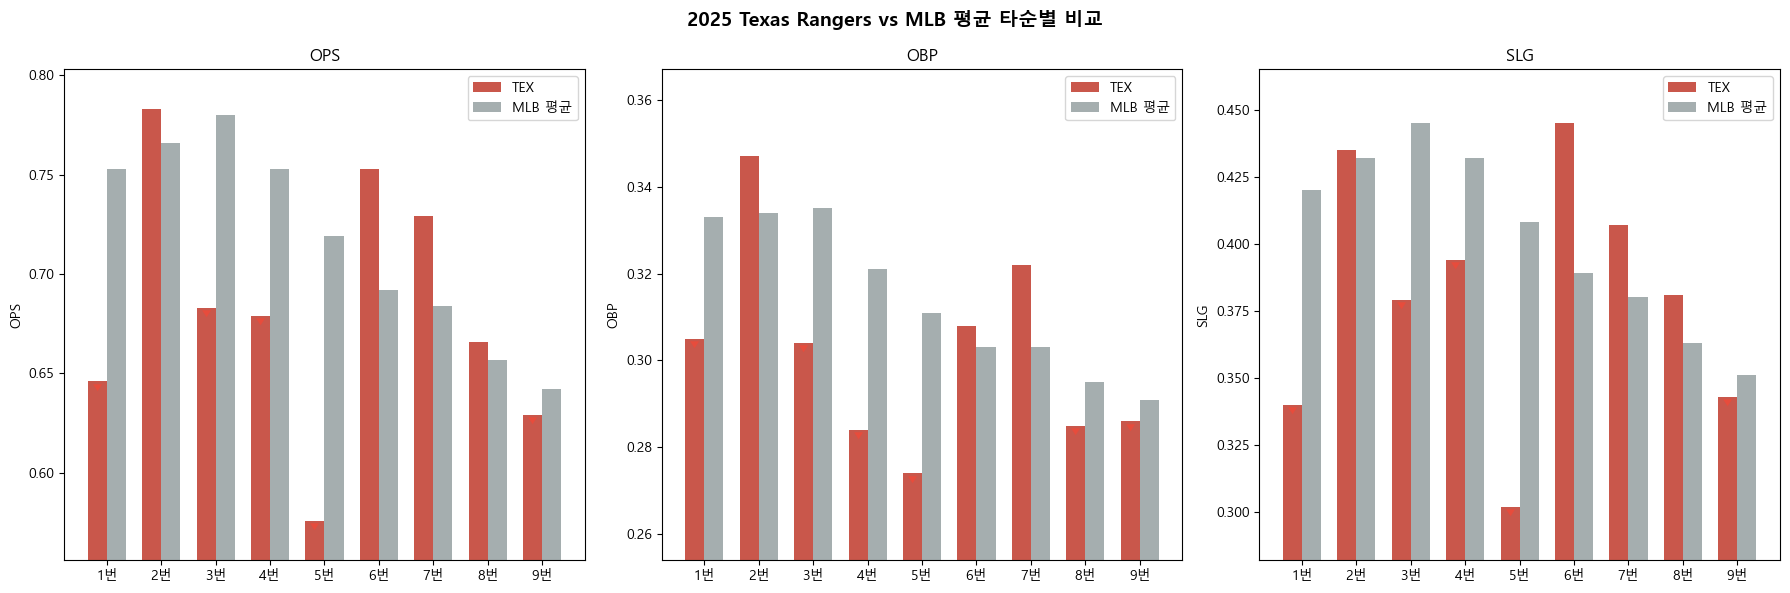


=== TEX - MLB 평균 OPS 차이 (타순별) ===
1번: -0.107 ★
2번: +0.017
3번: -0.097 ★
4번: -0.074 ★
5번: -0.143 ★
6번: +0.061 ★
7번: +0.045
8번: +0.009
9번: -0.013


In [3]:
import numpy as np

tex = pd.read_csv('./data/tex_2025_batting_order_splits.csv')
mlb = pd.read_csv('./data/mlb_2025_batting_order_splits.csv')

tex = tex[tex['Split'].str.startswith('Batting')].copy().reset_index(drop=True)
mlb = mlb[mlb['Split'].str.startswith('Batting')].copy().reset_index(drop=True)
orders = list(range(1, 10))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('2025 Texas Rangers vs MLB 평균 타순별 비교', fontsize=14, fontweight='bold')

metrics = [('OPS', 'OPS'), ('OBP', 'OBP'), ('SLG', 'SLG')]

for ax, (col, label) in zip(axes, metrics):
    x = np.arange(len(orders))
    w = 0.35
    tex_vals = tex[col].values
    mlb_vals = mlb[col].values

    bars_tex = ax.bar(x - w/2, tex_vals, w, label='TEX', color='#C0392B', alpha=0.85)
    bars_mlb = ax.bar(x + w/2, mlb_vals, w, label='MLB 평균', color='#7F8C8D', alpha=0.7)

    # TEX가 MLB보다 낮은 타순 강조
    for i, (t, m) in enumerate(zip(tex_vals, mlb_vals)):
        if t < m:
            ax.annotate('▼', xy=(x[i] - w/2, t), ha='center', va='top',
                        fontsize=8, color='#E74C3C')

    ax.set_xticks(x)
    ax.set_xticklabels([f'{i}번' for i in orders])
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend()
    ymin = min(tex_vals.min(), mlb_vals.min()) - 0.02
    ymax = max(tex_vals.max(), mlb_vals.max()) + 0.02
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

# 차이 요약 출력
print('\n=== TEX - MLB 평균 OPS 차이 (타순별) ===')
for i, (t, m) in enumerate(zip(tex['OPS'], mlb['OPS'])):
    diff = t - m
    sign = '+' if diff >= 0 else ''
    flag = ' ★' if abs(diff) >= 0.05 else ''
    print(f'{i+1}번: {sign}{diff:.3f}{flag}')


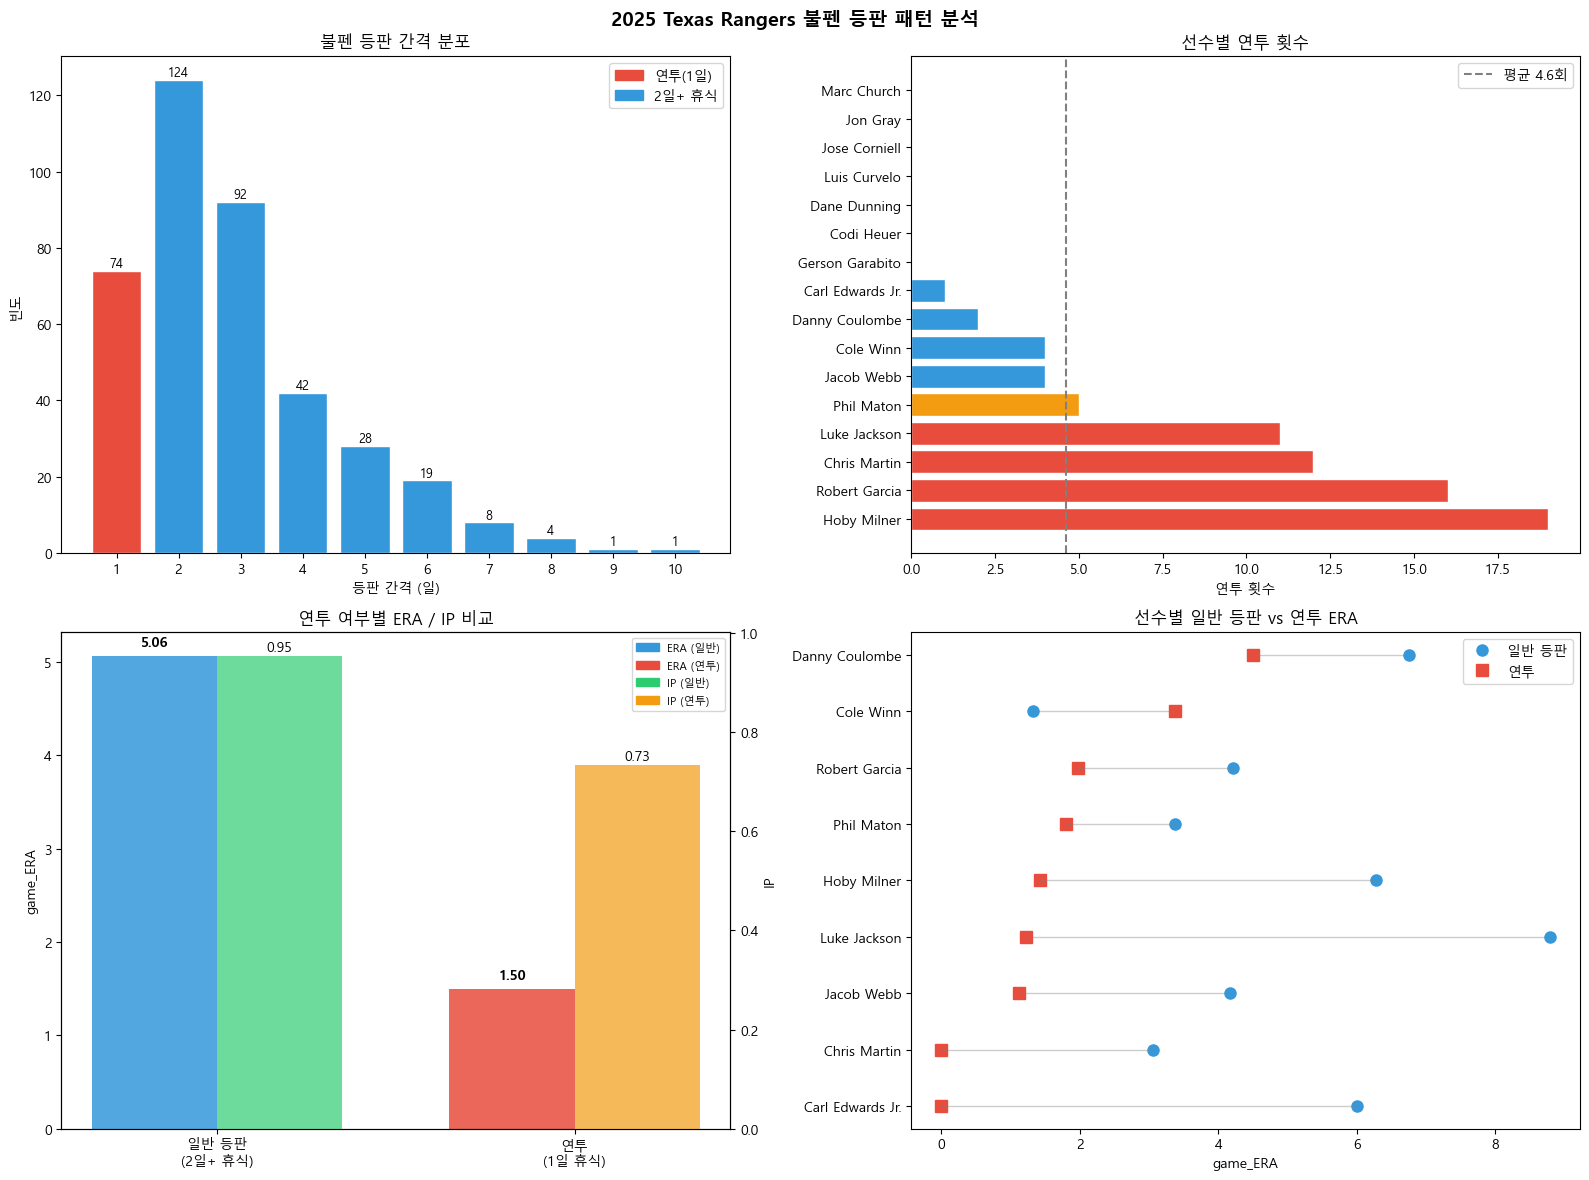

=== 연투 현황 요약 ===
전체 불펜 등판: 422회
연투 등판: 74회 (17.5%)

연투 TOP3: {'Hoby Milner': 19, 'Robert Garcia': 16, 'Chris Martin': 12}

game_ERA — 일반: 5.06 / 연투: 1.50
IP       — 일반: 0.95 / 연투: 0.73


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import platform

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

pit = pd.read_csv('./data/rangers_pitcher_gamelogs.csv')
gs_sum = pit.groupby('name')['GS'].sum()
bullpen_names = gs_sum[gs_sum == 0].index.tolist()
bp = pit[pit['name'].isin(bullpen_names)].copy()
bp['Date'] = pd.to_datetime(bp['Date'])
bp = bp.sort_values(['name', 'Date']).reset_index(drop=True)

# 같은 선수 & 1일 간격 → 연투
same_player = bp['name'] == bp['name'].shift(1)
rest_days   = bp['Date'].diff().dt.days
bp = bp.assign(
    rest_days = rest_days.where(same_player),
    is_consec = same_player & (rest_days == 1)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('2025 Texas Rangers 불펜 등판 패턴 분석', fontsize=14, fontweight='bold')

# --- 1) 등판 간격 분포 ---
ax1 = axes[0][0]
interval_counts = bp['rest_days'].dropna().value_counts().sort_index()
interval_counts = interval_counts[interval_counts.index <= 10]
colors_interval = ['#E74C3C' if i == 1 else '#3498DB' for i in interval_counts.index]
ax1.bar(interval_counts.index.astype(int), interval_counts.values, color=colors_interval, edgecolor='white')
ax1.set_xlabel('등판 간격 (일)')
ax1.set_ylabel('빈도')
ax1.set_title('불펜 등판 간격 분포')
ax1.set_xticks(range(1, 11))
for x, y in zip(interval_counts.index.astype(int), interval_counts.values):
    ax1.text(x, y + 1, str(y), ha='center', fontsize=9)
ax1.legend(handles=[
    mpatches.Patch(color='#E74C3C', label='연투(1일)'),
    mpatches.Patch(color='#3498DB', label='2일+ 휴식')
])

# --- 2) 선수별 연투 횟수 ---
ax2 = axes[0][1]
consec_by_player = bp.groupby('name')['is_consec'].sum().sort_values(ascending=False)
bar_colors = ['#E74C3C' if v >= 10 else '#F39C12' if v >= 5 else '#3498DB'
              for v in consec_by_player.values]
ax2.barh(consec_by_player.index, consec_by_player.values, color=bar_colors, edgecolor='white')
ax2.set_xlabel('연투 횟수')
ax2.set_title('선수별 연투 횟수')
ax2.axvline(consec_by_player.mean(), color='gray', linestyle='--',
            label=f'평균 {consec_by_player.mean():.1f}회')
ax2.legend()

# --- 3) 연투 여부별 성적 비교 ---
ax3 = axes[1][0]
era_vals = [bp[~bp['is_consec']]['game_ERA'].mean(), bp[bp['is_consec']]['game_ERA'].mean()]
ip_vals  = [bp[~bp['is_consec']]['IP'].mean(),       bp[bp['is_consec']]['IP'].mean()]
x = np.arange(2)
w = 0.35
b1 = ax3.bar(x - w/2, era_vals, w, color=['#3498DB', '#E74C3C'], alpha=0.85)
ax3_r = ax3.twinx()
b2 = ax3_r.bar(x + w/2, ip_vals, w, color=['#2ECC71', '#F39C12'], alpha=0.7)
ax3.set_xticks(x)
ax3.set_xticklabels(['일반 등판\n(2일+ 휴식)', '연투\n(1일 휴식)'])
ax3.set_ylabel('game_ERA')
ax3_r.set_ylabel('IP')
ax3.set_title('연투 여부별 ERA / IP 비교')
for bar, val in zip(b1, era_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
for bar, val in zip(b2, ip_vals):
    ax3_r.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{val:.2f}', ha='center', fontsize=10)
ax3.legend(handles=[
    mpatches.Patch(color='#3498DB', label='ERA (일반)'),
    mpatches.Patch(color='#E74C3C', label='ERA (연투)'),
    mpatches.Patch(color='#2ECC71', label='IP (일반)'),
    mpatches.Patch(color='#F39C12', label='IP (연투)')
], loc='upper right', fontsize=8)

# --- 4) 선수별 일반 vs 연투 ERA ---
ax4 = axes[1][1]
player_era = bp.groupby(['name', 'is_consec'])['game_ERA'].mean().unstack(fill_value=np.nan)
player_era.columns = ['일반', '연투']
player_era = player_era.dropna().sort_values('연투')
ax4.plot(player_era['일반'], player_era.index, 'o', color='#3498DB', label='일반 등판', markersize=8)
ax4.plot(player_era['연투'],  player_era.index, 's', color='#E74C3C', label='연투',     markersize=8)
for name in player_era.index:
    ax4.plot([player_era.loc[name, '일반'], player_era.loc[name, '연투']],
             [name, name], color='gray', alpha=0.4, linewidth=1)
ax4.set_xlabel('game_ERA')
ax4.set_title('선수별 일반 등판 vs 연투 ERA')
ax4.legend()

plt.tight_layout()
plt.show()

print('=== 연투 현황 요약 ===')
print(f'전체 불펜 등판: {len(bp)}회')
print(f'연투 등판: {bp["is_consec"].sum()}회 ({bp["is_consec"].mean()*100:.1f}%)')
print(f'\n연투 TOP3: {consec_by_player.head(3).to_dict()}')
print(f'\ngame_ERA — 일반: {era_vals[0]:.2f} / 연투: {era_vals[1]:.2f}')
print(f'IP       — 일반: {ip_vals[0]:.2f} / 연투: {ip_vals[1]:.2f}')


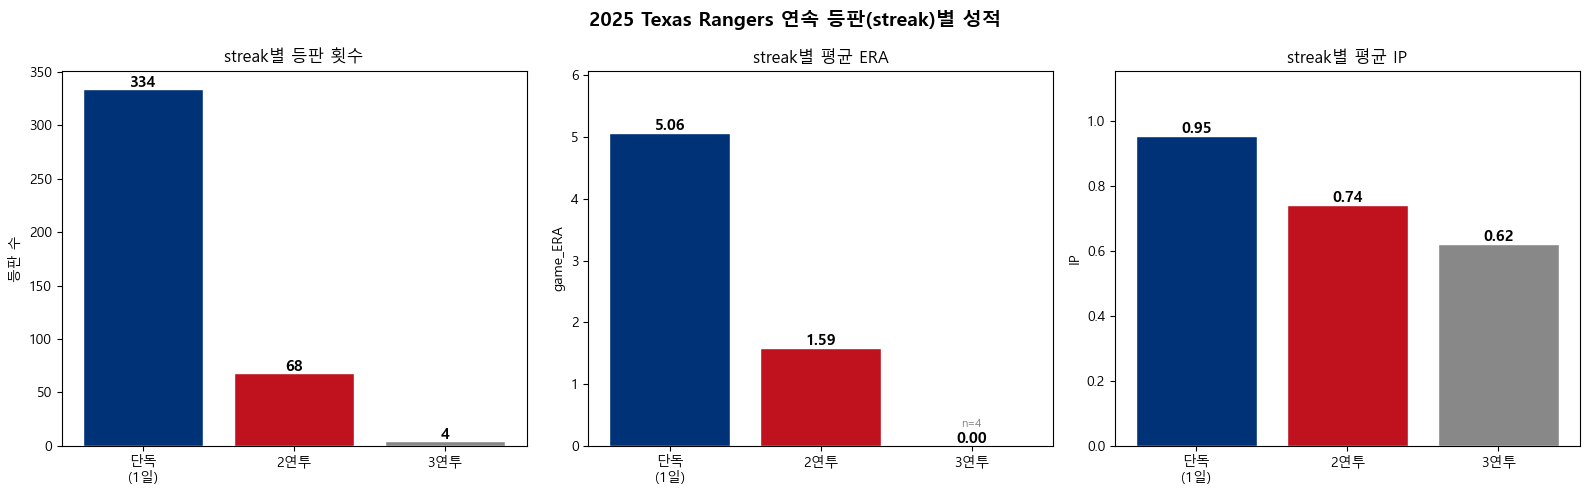

=== 3연투 등판 상세 ===
        name       Date  IP  game_ERA  SO  BB
Chris Martin 2025-05-13 0.0       NaN   0   0
 Hoby Milner 2025-05-28 0.1       0.0   1   0
 Hoby Milner 2025-06-14 1.0       0.0   1   0
 Hoby Milner 2025-07-21 1.0       0.0   0   0
Luke Jackson 2025-06-15 1.0       0.0   1   0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import platform



pit = pd.read_csv('./data/rangers_pitcher_gamelogs.csv')
gs_sum = pit.groupby('name')['GS'].sum()
bullpen_names = gs_sum[gs_sum == 0].index.tolist()
bp = pit[pit['name'].isin(bullpen_names)].copy()
bp['Date'] = pd.to_datetime(bp['Date'])
bp = bp.sort_values(['name', 'Date']).reset_index(drop=True)

# rest_days: 같은 선수 내에서만 유효
bp['rest_days'] = bp['Date'].diff().dt.days
bp.loc[bp['name'] != bp['name'].shift(1), 'rest_days'] = np.nan

# streak 계산
streaks = []
cur = 1
for i in range(len(bp)):
    if i == 0:
        streaks.append(1)
        continue
    same_player = bp.loc[i, 'name'] == bp.loc[i-1, 'name']
    if same_player and bp.loc[i, 'rest_days'] == 1:
        cur += 1
    else:
        cur = 1
    streaks.append(cur)
bp['streak'] = streaks

streak_stats = bp.groupby('streak').agg(
    count=('game_ERA', 'count'),
    ERA=('game_ERA', 'mean'),
    IP=('IP', 'mean'),
    SO=('SO', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('2025 Texas Rangers 연속 등판(streak)별 성적', fontsize=14, fontweight='bold')
tex_blue = '#003278'
tex_red = '#C0111F'
mlb_gray = '#888888'
bg_color = '#FAFAFA'
grid_color = '#E0E0E0'

streak_labels = {1: '단독\n(1일)', 2: '2연투', 3: '3연투'}
x_labels = [streak_labels.get(s, f'{s}연투') for s in streak_stats['streak']]
colors = [tex_blue, tex_red, mlb_gray]


# --- 1) 등판 횟수 ---
ax1 = axes[0]
bars = ax1.bar(x_labels, streak_stats['count'], color=colors, edgecolor='white')
for bar, cnt in zip(bars, streak_stats['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(cnt), ha='center', fontsize=11, fontweight='bold')
ax1.set_title('streak별 등판 횟수')
ax1.set_ylabel('등판 수')

# --- 2) ERA ---
ax2 = axes[1]
bars2 = ax2.bar(x_labels, streak_stats['ERA'], color=colors, edgecolor='white')
for bar, val, cnt in zip(bars2, streak_stats['ERA'], streak_stats['count']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
    if cnt < 15:
        ax2.text(bar.get_x() + bar.get_width()/2, 0.3,
                 f'n={cnt}', ha='center', fontsize=8, color='gray')
ax2.set_title('streak별 평균 ERA')
ax2.set_ylabel('game_ERA')
ax2.set_ylim(0, streak_stats['ERA'].max() + 1)

# --- 3) IP ---
ax3 = axes[2]
bars3 = ax3.bar(x_labels, streak_stats['IP'], color=colors, edgecolor='white')
for bar, val in zip(bars3, streak_stats['IP']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax3.set_title('streak별 평균 IP')
ax3.set_ylabel('IP')
ax3.set_ylim(0, streak_stats['IP'].max() + 0.2)

plt.tight_layout()
plt.show()

print('=== 3연투 등판 상세 ===')
print(bp[bp['streak'] == 3][['name', 'Date', 'IP', 'game_ERA', 'SO', 'BB']].to_string(index=False))


## 홈 vs 원정

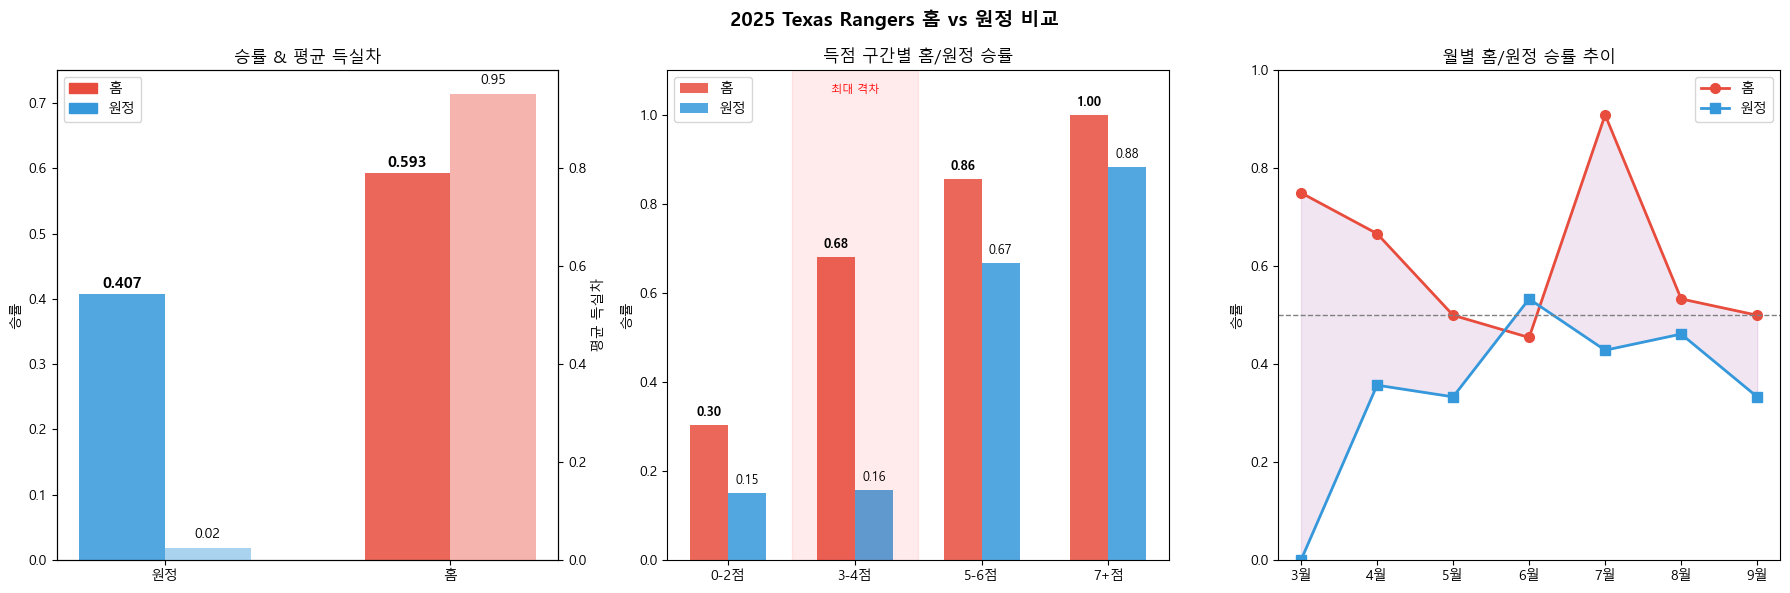

=== 홈/원정 요약 ===
원정: 33승 48패 (승률 0.407) | 평균 득점 4.41 / 실점 4.38
홈: 48승 33패 (승률 0.593) | 평균 득점 4.04 / 실점 3.09

3-4점 득점 시 홈 승률: 0.682 / 원정 승률: 0.158


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import platform


df = pd.read_csv('./data/texas_2025_game_log.csv')
df['is_home'] = df['Home_Away'] == 'Home'
df['win'] = df['W/L'].str.startswith('W')
df['run_diff'] = df['R'] - df['RA']
df['score_cat'] = pd.cut(df['R'], bins=[0,2,4,6,100], labels=['0-2점','3-4점','5-6점','7+점'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('2025 Texas Rangers 홈 vs 원정 비교', fontsize=14, fontweight='bold')

summary = df.groupby('is_home').agg(
    games=('win','count'), wins=('win','sum'),
    R=('R','mean'), RA=('RA','mean'), run_diff=('run_diff','mean')
).reset_index()
summary['win_pct'] = summary['wins'] / summary['games']
labels = ['원정', '홈']
colors = ['#3498DB', '#E74C3C']
x = np.arange(2)
w = 0.3

# --- 1) 승률 & 득실차 ---
ax1 = axes[0]
ax1b = ax1.twinx()
b1 = ax1.bar(x - w/2, summary['win_pct'], w, color=colors, alpha=0.85)
b2 = ax1b.bar(x + w/2, summary['run_diff'], w, color=['#85C1E9','#F1948A'], alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('승률')
ax1b.set_ylabel('평균 득실차')
ax1.set_title('승률 & 평균 득실차')
ax1.set_ylim(0, 0.75)
for bar, val in zip(b1, summary['win_pct']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
for bar, val in zip(b2, summary['run_diff']):
    ax1b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
              f'{val:.2f}', ha='center', fontsize=10)
ax1.legend(handles=[
    mpatches.Patch(color='#E74C3C', label='홈'),
    mpatches.Patch(color='#3498DB', label='원정'),
], loc='upper left')

# --- 2) 득점 구간별 승률 ---
ax2 = axes[1]
cats = ['0-2점','3-4점','5-6점','7+점']
win_home = df[df['is_home']].groupby('score_cat', observed=True)['win'].mean().reindex(cats)
win_away = df[~df['is_home']].groupby('score_cat', observed=True)['win'].mean().reindex(cats)
x2 = np.arange(len(cats))
ax2.bar(x2 - w/2, win_home, w, color='#E74C3C', alpha=0.85, label='홈')
ax2.bar(x2 + w/2, win_away, w, color='#3498DB', alpha=0.85, label='원정')
for i, (h, a) in enumerate(zip(win_home, win_away)):
    if not np.isnan(h): ax2.text(i-w/2, h+0.02, f'{h:.2f}', ha='center', fontsize=9, fontweight='bold')
    if not np.isnan(a): ax2.text(i+w/2, a+0.02, f'{a:.2f}', ha='center', fontsize=9)
ax2.set_xticks(x2)
ax2.set_xticklabels(cats)
ax2.set_ylabel('승률')
ax2.set_title('득점 구간별 홈/원정 승률')
ax2.set_ylim(0, 1.1)
ax2.legend()
ax2.axvspan(0.5, 1.5, alpha=0.08, color='red')
ax2.text(1, 1.05, '최대 격차', ha='center', fontsize=8, color='red')

# --- 3) 월별 추이 ---
ax3 = axes[2]
df['Date_parsed'] = pd.to_datetime(df['Date'].str.extract(r'(\w+ \d+)')[0] + ' 2025',
                                    format='%b %d %Y', errors='coerce')
df['month'] = df['Date_parsed'].dt.month
monthly = df.groupby(['month','is_home'])['win'].mean().unstack()
monthly.columns = ['원정','홈']
monthly.index = ['3월','4월','5월','6월','7월','8월','9월']
ax3.plot(monthly.index, monthly['홈'],  'o-', color='#E74C3C', linewidth=2, label='홈',  markersize=7)
ax3.plot(monthly.index, monthly['원정'],'s-', color='#3498DB', linewidth=2, label='원정', markersize=7)
ax3.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax3.fill_between(monthly.index, monthly['홈'], monthly['원정'], alpha=0.1, color='purple')
ax3.set_ylabel('승률')
ax3.set_title('월별 홈/원정 승률 추이')
ax3.set_ylim(0, 1.0)
ax3.legend()

plt.tight_layout()
plt.show()

print('=== 홈/원정 요약 ===')
for _, row in summary.iterrows():
    label = '홈' if row['is_home'] else '원정'
    print(f'{label}: {int(row["wins"])}승 {int(row["games"]-row["wins"])}패 '
          f'(승률 {row["win_pct"]:.3f}) | 평균 득점 {row["R"]:.2f} / 실점 {row["RA"]:.2f}')
print(f'\n3-4점 득점 시 홈 승률: {win_home["3-4점"]:.3f} / 원정 승률: {win_away["3-4점"]:.3f}')


## 접전 상황 승률

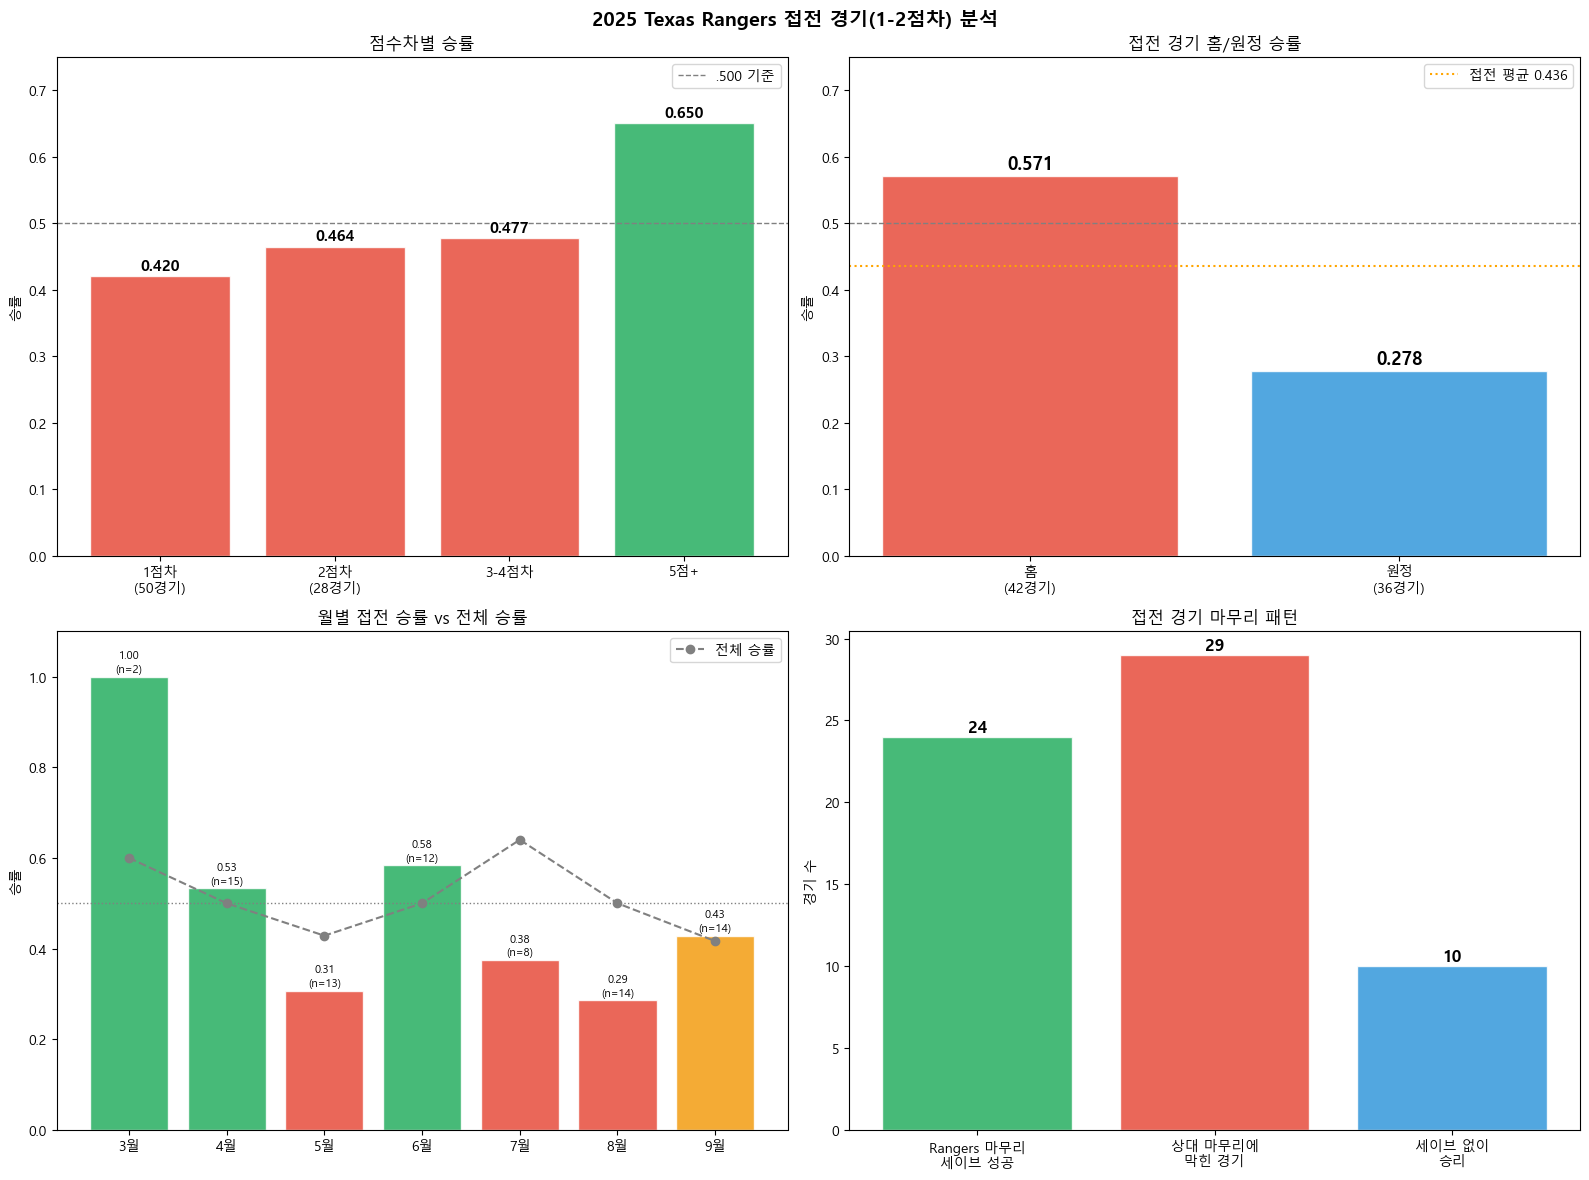

=== 접전 경기 핵심 요약 ===
전체 접전 경기: 78경기 (시즌의 48.1%)
접전 승률: 0.436 (홈 0.571 / 원정 0.278)
Rangers 마무리 세이브: 24경기 / 상대 마무리에 막힌 경기: 29경기


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import platform



df = pd.read_csv('./data/texas_2025_game_log.csv')
df['is_home'] = df['Home_Away'] == 'Home'
df['win'] = df['W/L'].str.startswith('W')
df['run_diff'] = df['R'] - df['RA']
df['abs_diff'] = df['run_diff'].abs()
df['Date_parsed'] = pd.to_datetime(df['Date'].str.extract(r',\s*(\w+ \d+)')[0] + ' 2025',
                                    format='%b %d %Y', errors='coerce')
df['month'] = df['Date_parsed'].dt.month

close   = df[df['abs_diff'] <= 2].copy()
blowout = df[df['abs_diff'] >= 5].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('2025 Texas Rangers 접전 경기(1-2점차) 분석', fontsize=14, fontweight='bold')

# --- 1) 점수차별 승률 ---
ax1 = axes[0][0]
type_labels = ['1점차\n(50경기)', '2점차\n(28경기)', '3-4점차', '5점+']
type_wins = [
    df[df['abs_diff']==1]['win'].mean(),
    df[df['abs_diff']==2]['win'].mean(),
    df[(df['abs_diff']>=3)&(df['abs_diff']<=4)]['win'].mean(),
    blowout['win'].mean()
]
colors = ['#E74C3C' if v < 0.5 else '#27AE60' for v in type_wins]
bars = ax1.bar(type_labels, type_wins, color=colors, edgecolor='white', alpha=0.85)
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='.500 기준')
for bar, val in zip(bars, type_wins):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylabel('승률')
ax1.set_title('점수차별 승률')
ax1.set_ylim(0, 0.75)
ax1.legend()

# --- 2) 접전 홈/원정 승률 ---
ax2 = axes[0][1]
hw = close[close['is_home']]['win'].mean()
aw = close[~close['is_home']]['win'].mean()
hc = len(close[close['is_home']])
ac = len(close[~close['is_home']])
bars2 = ax2.bar([f'홈\n({hc}경기)', f'원정\n({ac}경기)'],
                [hw, aw], color=['#E74C3C', '#3498DB'], edgecolor='white', alpha=0.85)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax2.axhline(close['win'].mean(), color='orange', linestyle=':', linewidth=1.5,
            label=f'접전 평균 {close["win"].mean():.3f}')
for bar, val in zip(bars2, [hw, aw]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=13, fontweight='bold')
ax2.set_ylabel('승률')
ax2.set_title('접전 경기 홈/원정 승률')
ax2.set_ylim(0, 0.75)
ax2.legend()

# --- 3) 월별 접전 승률 ---
ax3 = axes[1][0]
month_close = close.groupby('month')['win'].agg(['mean','count']).reset_index()
month_all   = df.groupby('month')['win'].mean().reset_index()
month_labels = {3:'3월',4:'4월',5:'5월',6:'6월',7:'7월',8:'8월',9:'9월'}
month_close['label'] = month_close['month'].map(month_labels)
x3 = np.arange(len(month_close))
bar_colors = ['#E74C3C' if v < 0.4 else '#F39C12' if v < 0.5 else '#27AE60'
              for v in month_close['mean']]
bars3 = ax3.bar(x3, month_close['mean'], color=bar_colors, edgecolor='white', alpha=0.85)
ax3.plot(x3, month_all['win'].values[:len(x3)], 'o--', color='gray',
         linewidth=1.5, label='전체 승률', markersize=6)
ax3.axhline(0.5, color='gray', linestyle=':', linewidth=1)
for bar, val, cnt in zip(bars3, month_close['mean'], month_close['count']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.2f}\n(n={cnt})', ha='center', fontsize=8)
ax3.set_xticks(x3)
ax3.set_xticklabels(month_close['label'])
ax3.set_ylabel('승률')
ax3.set_title('월별 접전 승률 vs 전체 승률')
ax3.set_ylim(0, 1.1)
ax3.legend()

# --- 4) 접전 경기 마무리 패턴 ---
ax4 = axes[1][1]
rangers_save  = close[close['Save'].notna() & close['win']]['win'].count()
opp_save      = close[close['Save'].notna() & ~close['win']]['win'].count()
no_save_win   = close[~close['Save'].notna() & close['win']]['win'].count()
categories = ['Rangers 마무리\n세이브 성공', '상대 마무리에\n막힌 경기', '세이브 없이\n승리']
values = [rangers_save, opp_save, no_save_win]
colors4 = ['#27AE60', '#E74C3C', '#3498DB']
bars4 = ax4.bar(categories, values, color=colors4, edgecolor='white', alpha=0.85)
for bar, val in zip(bars4, values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             str(val), ha='center', fontsize=12, fontweight='bold')
ax4.set_ylabel('경기 수')
ax4.set_title('접전 경기 마무리 패턴')

plt.tight_layout()
plt.show()

print('=== 접전 경기 핵심 요약 ===')
print(f'전체 접전 경기: {len(close)}경기 (시즌의 {len(close)/len(df)*100:.1f}%)')
print(f'접전 승률: {close["win"].mean():.3f} (홈 {hw:.3f} / 원정 {aw:.3f})')
print(f'Rangers 마무리 세이브: {rangers_save}경기 / 상대 마무리에 막힌 경기: {opp_save}경기')


## SV와 BS

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import platform



sv = pd.read_csv('./data/tex_2025_save_situation_splits.csv')
sv_team = sv[sv['Name'] == 'Team Total'].iloc[0]
sv = sv[sv['Name'] != 'Team Total'].copy()
sv['SVO'] = sv['SV'] + sv['BS']
sv['SV_pct'] = (sv['SV'] / sv['SVO']).round(3)
sv = sv[sv['SVO'] > 0].sort_values('SVO', ascending=False).reset_index(drop=True)

print(sv[['Name','G','SV','BS','SVO','SV_pct','ERA','WHIP']].to_string(index=False))

           Name  G  SV  BS  SVO  SV_pct   ERA  WHIP
  Robert Garcia 31   9   7   16   0.562  5.04 1.640
Shawn Armstrong 24   9   3   12   0.750  3.86 1.000
   Luke Jackson 15   9   2   11   0.818  2.08 1.077
     Phil Maton  8   3   3    6   0.500  5.63 1.125
   Chris Martin 20   2   3    5   0.400  3.00 1.067
    Hoby Milner 24   0   4    4   0.000  2.82 1.164
     Jacob Webb 10   1   2    3   0.333  3.72 1.448
       Jon Gray  2   0   2    2   0.000 12.27 1.909
   Dane Dunning  2   2   0    2   1.000  3.00 1.500
   Luis Curvelo  4   0   2    2   0.000  3.00 1.000
     Jacob Latz  2   1   0    1   1.000  0.00 0.500
    Marc Church  2   0   1    1   0.000 13.50 3.000
 Caleb Boushley  1   1   0    1   1.000  3.00 0.667


In [24]:
sv.columns

Index(['Rk', 'Name', 'W', 'L', 'W-L%', 'ERA', 'G', 'GS', 'GF', 'CG', 'SHO',
       'SV', 'IP', 'H', 'R', 'ER', 'HR', 'BB', 'IBB', 'SO', 'HBP', 'BK', 'WP',
       'BF', 'WHIP', 'SO9', 'SO/W', 'Name-additional', 'BS', 'SVO', 'SV_pct'],
      dtype='str')

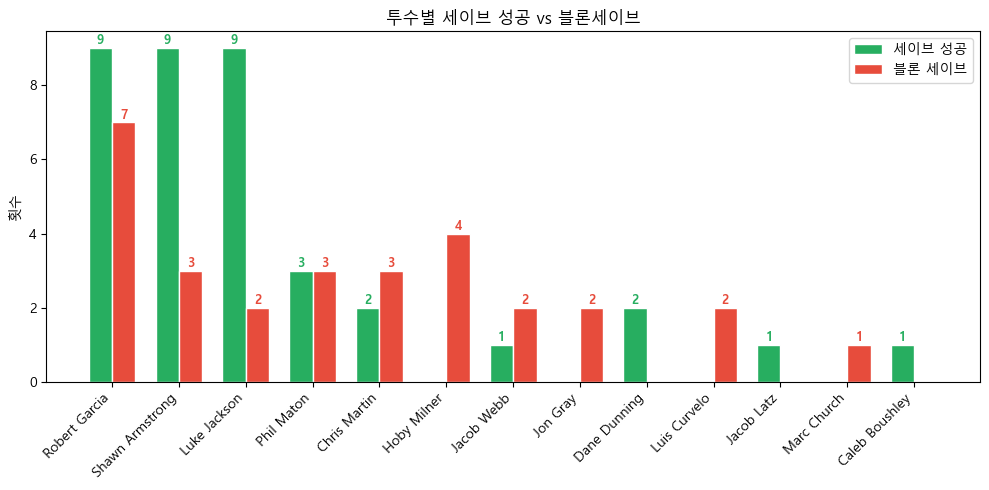

In [29]:
# 세이브 성공 vs 블론세이브
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(sv))
w = 0.35
ax.bar(x - w/2, sv['SV'], w, color='#27AE60', label='세이브 성공', edgecolor='white')
ax.bar(x + w/2, sv['BS'],  w, color='#E74C3C', label='블론 세이브', edgecolor='white')
for i, (sv_val, l_val) in enumerate(zip(sv['SV'], sv['BS'])):
    if sv_val > 0:
        ax.text(i-w/2, sv_val+0.1, str(sv_val), ha='center', fontsize=9, fontweight='bold', color='#27AE60')
    if l_val > 0:
        ax.text(i+w/2, l_val+0.1, str(l_val), ha='center', fontsize=9, fontweight='bold', color='#E74C3C')
ax.set_xticks(x)
ax.set_xticklabels(sv['Name'], rotation=45, ha='right')
ax.set_ylabel('횟수')
ax.set_title('투수별 세이브 성공 vs 블론세이브')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\chanhyeok\AppData\Local\Temp\ipykernel_8036\921215233.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sv['Name'], rotation=45, ha='right')


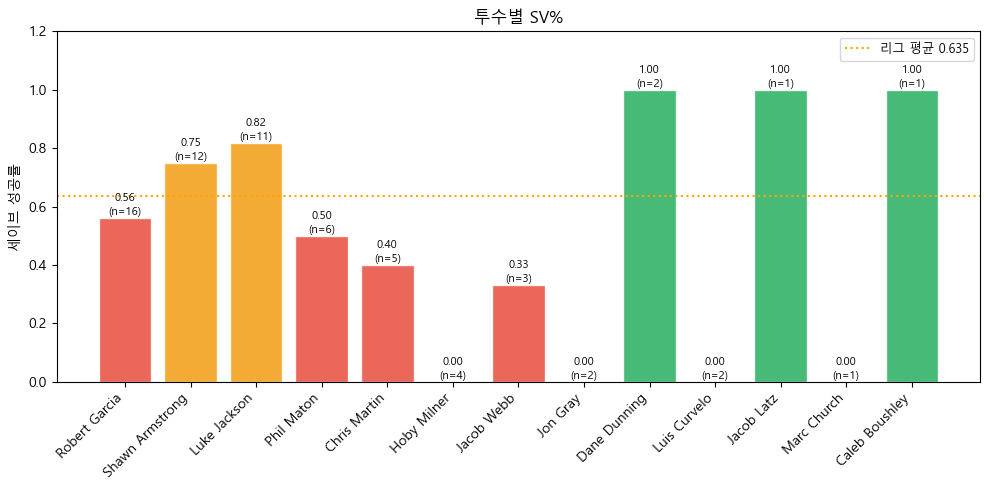

In [33]:
# SV% (세이브 성공률)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27AE60' if v >= 0.85 else '#F39C12' if v >= 0.75 else '#E74C3C'
          for v in sv['SV_pct']]
bars = ax.bar(sv['Name'], sv['SV_pct'], color=colors, edgecolor='white', alpha=0.85)
# ax.axhline(0.85, color='gray', linestyle='--', linewidth=1, label='우수 기준 (0.85)')
ax.axhline(1201/1891, color='orange', linestyle=':', linewidth=1.5,
           label=f'리그 평균 {1201/1891:.3f}')
for bar, val, svo in zip(bars, sv['SV_pct'], sv['SVO']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.2f}\n(n={svo})', ha='center', fontsize=8)
ax.set_xticklabels(sv['Name'], rotation=45, ha='right')
ax.set_ylabel('세이브 성공률')
ax.set_title('투수별 SV%')
ax.set_ylim(0, 1.2)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

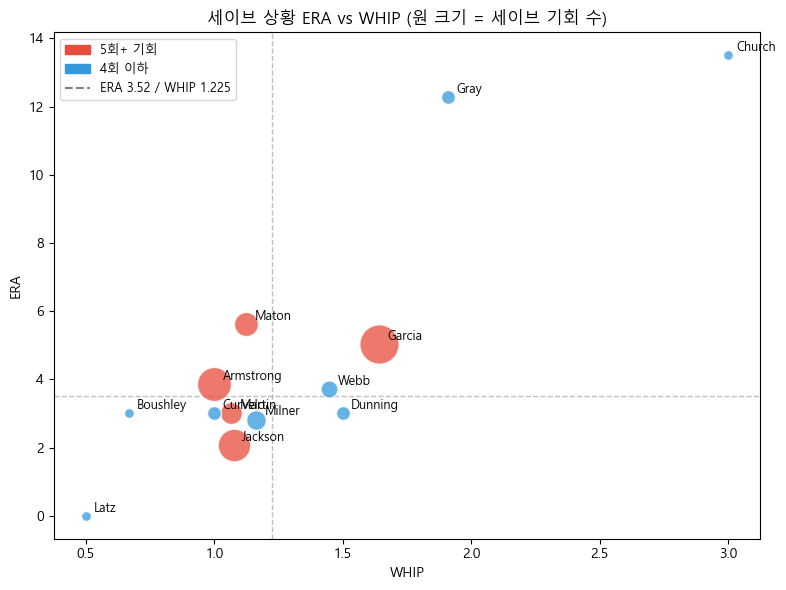

In [38]:
# ERA vs WHIP 산점도
fig, ax = plt.subplots(figsize=(8, 6))
for _, row in sv.iterrows():
    c = '#E74C3C' if row['SVO'] >= 5 else '#3498DB'
    ax.scatter(row['WHIP'], row['ERA'], s=row['SVO']*50, color=c, alpha=0.75,
               edgecolor='white', zorder=3)
    ax.annotate(row['Name'].split()[-1], (row['WHIP'], row['ERA']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
ax.axvline(1.225, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='WHIP 1.225')
ax.axhline(3.52, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='ERA 3.51')
ax.set_xlabel('WHIP')
ax.set_ylabel('ERA')
ax.set_title('세이브 상황 ERA vs WHIP (원 크기 = 세이브 기회 수)')
ax.legend(handles=[
    mpatches.Patch(color='#E74C3C', label='5회+ 기회'),
    mpatches.Patch(color='#3498DB', label='4회 이하'),
    plt.Line2D([0],[0], color='gray', linestyle='--', label='ERA 3.52 / WHIP 1.225')
], fontsize=9)
plt.tight_layout()
plt.show()

In [36]:
# 요약
print('=== 팀 세이브 상황 요약 ===')
print(f'세이브 기회: {int(sv_team["SV"]+sv_team["BS"])}회')
print(f'성공: {int(sv_team["SV"])}회 / 블론: {int(sv_team["BS"])}회')
print(f'팀 SV%: {sv_team["SV"]/(sv_team["SV"]+sv_team["L"]):.3f}')
print()
print('=== SVO 5회 이상 투수 ===')
for _, row in sv[sv['SVO']>=5].iterrows():
    print(f'{row["Name"]}: SVO {int(row["SVO"])} | SV% {row["SV_pct"]:.3f} | ERA {row["ERA"]:.2f} | WHIP {row["WHIP"]:.3f}')

=== 팀 세이브 상황 요약 ===
세이브 기회: 66회
성공: 37회 / 블론: 29회
팀 SV%: 0.787

=== SVO 5회 이상 투수 ===
Robert Garcia: SVO 16 | SV% 0.562 | ERA 5.04 | WHIP 1.640
Shawn Armstrong: SVO 12 | SV% 0.750 | ERA 3.86 | WHIP 1.000
Luke Jackson: SVO 11 | SV% 0.818 | ERA 2.08 | WHIP 1.077
Phil Maton: SVO 6 | SV% 0.500 | ERA 5.63 | WHIP 1.125
Chris Martin: SVO 5 | SV% 0.400 | ERA 3.00 | WHIP 1.067


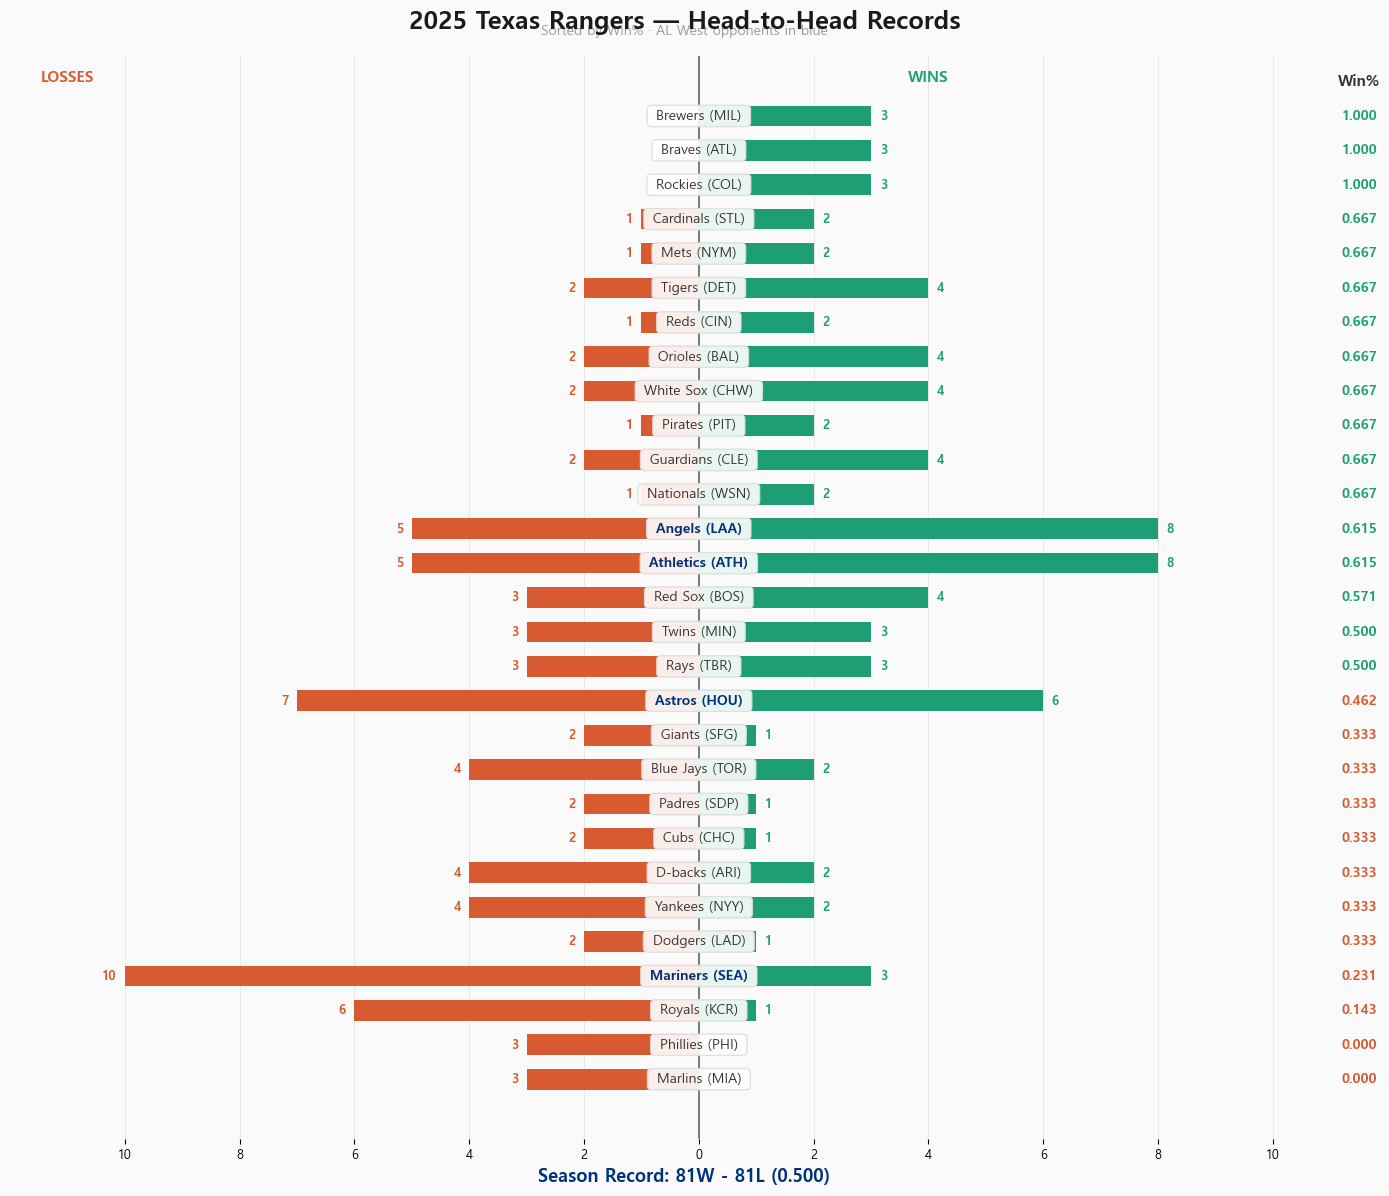

Saved: tex_2025_head_to_head.png


In [13]:
game_log = pd.read_csv('./data/texas_2025_game_log.csv')

# ── 날짜 변환 (텍스트 형식인 경우) ──
# game_log['Date'] = pd.to_datetime(game_log['Date'] + ', 2025', format='%A, %b %d, %Y')

# ── 승/패 분류 ──
game_log['Result'] = game_log['W/L'].apply(lambda x: 'W' if x in ['W','W-wo'] else 'L')

# ── 상대팀별 승패 집계 ──
records = game_log.groupby('Opp')['Result'].value_counts().unstack(fill_value=0)
records = records.reindex(columns=['W','L'], fill_value=0)
records['Total'] = records['W'] + records['L']
records['WinPct'] = (records['W'] / records['Total']).round(3)
records = records.sort_values('WinPct', ascending=True)

# ── 팀 약어 → 풀네임 ──
team_names = {
    'BOS':'Red Sox','CIN':'Reds','TBR':'Rays','CHC':'Cubs','SEA':'Mariners',
    'LAA':'Angels','LAD':'Dodgers','ATH':'Athletics','SFG':'Giants','DET':'Tigers',
    'COL':'Rockies','HOU':'Astros','NYY':'Yankees','CHW':'White Sox','TOR':'Blue Jays',
    'STL':'Cardinals','WSN':'Nationals','MIN':'Twins','KCR':'Royals','PIT':'Pirates',
    'BAL':'Orioles','SDP':'Padres','ATL':'Braves','PHI':'Phillies','ARI':'D-backs',
    'CLE':'Guardians','MIL':'Brewers','NYM':'Mets','MIA':'Marlins'
}

# ── AL West 팀 구분 ──
al_west = ['SEA','LAA','ATH','HOU']

# ── 색상 ──
bg_color = '#FAFAFA'
tex_blue = '#003278'
win_green = '#1D9E75'
loss_red = '#D85A30'

# ── 시각화 ──
fig, ax = plt.subplots(figsize=(14, 12), facecolor=bg_color)
ax.set_facecolor(bg_color)

y = np.arange(len(records))
bar_height = 0.6

# 승리 바 (오른쪽) / 패배 바 (왼쪽)
ax.barh(y, records['W'].values, height=bar_height, color=win_green, zorder=3)
ax.barh(y, -records['L'].values, height=bar_height, color=loss_red, zorder=3)

# 팀명 + 승/패 수 + 승률 표시
for i, (opp, row) in enumerate(records.iterrows()):
    name = team_names.get(opp, opp)
    weight = 'bold' if opp in al_west else 'normal'
    color = tex_blue if opp in al_west else '#333333'
    ax.text(0, i, f' {name} ({opp}) ', ha='center', va='center',
            fontsize=10, fontweight=weight, color=color, zorder=5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#ddd', alpha=0.9))
    if row['W'] > 0:
        ax.text(row['W'] + 0.15, i, str(int(row['W'])), ha='left', va='center',
                fontsize=9, fontweight='bold', color=win_green)
    if row['L'] > 0:
        ax.text(-row['L'] - 0.15, i, str(int(row['L'])), ha='right', va='center',
                fontsize=9, fontweight='bold', color=loss_red)
    pct_color = win_green if row['WinPct'] >= 0.5 else loss_red
    ax.text(max(records['W'].max(), records['L'].max()) + 1.5, i,
            f'{row["WinPct"]:.3f}', ha='center', va='center', fontsize=10,
            fontweight='bold', color=pct_color)

# 중앙선
ax.axvline(x=0, color='#666666', linewidth=1.2, zorder=4)

# 승률 헤더
ax.text(max(records['W'].max(), records['L'].max()) + 1.5, len(records),
        'Win%', ha='center', va='center', fontsize=11, fontweight='bold', color='#333')

# 축 설정
ax.set_yticks([])
ax.set_xlim(-max(records['L'].max(), 8) - 2, max(records['W'].max(), 8) + 3.5)
ax.set_xticks(range(-10, 11, 2))
ax.set_xticklabels([str(abs(t)) for t in range(-10, 11, 2)], fontsize=9)

# 그리드 및 스타일
ax.grid(axis='x', color='#E0E0E0', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

# 제목
ax.set_title('2025 Texas Rangers — Head-to-Head Records',
             fontsize=18, fontweight='bold', pad=20, color='#1a1a1a')
ax.text(0.5, 1.02, 'Sorted by Win% · AL West opponents in blue',
        transform=ax.transAxes, ha='center', fontsize=10, color='#999')

# WINS / LOSSES 라벨
ax.text(-max(records['L'].max(), 8) - 1, len(records), 'LOSSES',
        ha='center', fontsize=11, fontweight='bold', color=loss_red)
ax.text(max(records['W'].max(), 8) / 2, len(records), 'WINS',
        ha='center', fontsize=11, fontweight='bold', color=win_green)

# 시즌 전체 기록
total_w = records['W'].sum()
total_l = records['L'].sum()
ax.text(0.5, -0.04,
        f'Season Record: {int(total_w)}W - {int(total_l)}L ({total_w/(total_w+total_l):.3f})',
        transform=ax.transAxes, ha='center', fontsize=13, fontweight='bold', color=tex_blue)

plt.tight_layout()
plt.savefig('tex_2025_head_to_head.png', dpi=200, bbox_inches='tight', facecolor=bg_color)
plt.show()
print("Saved: tex_2025_head_to_head.png")

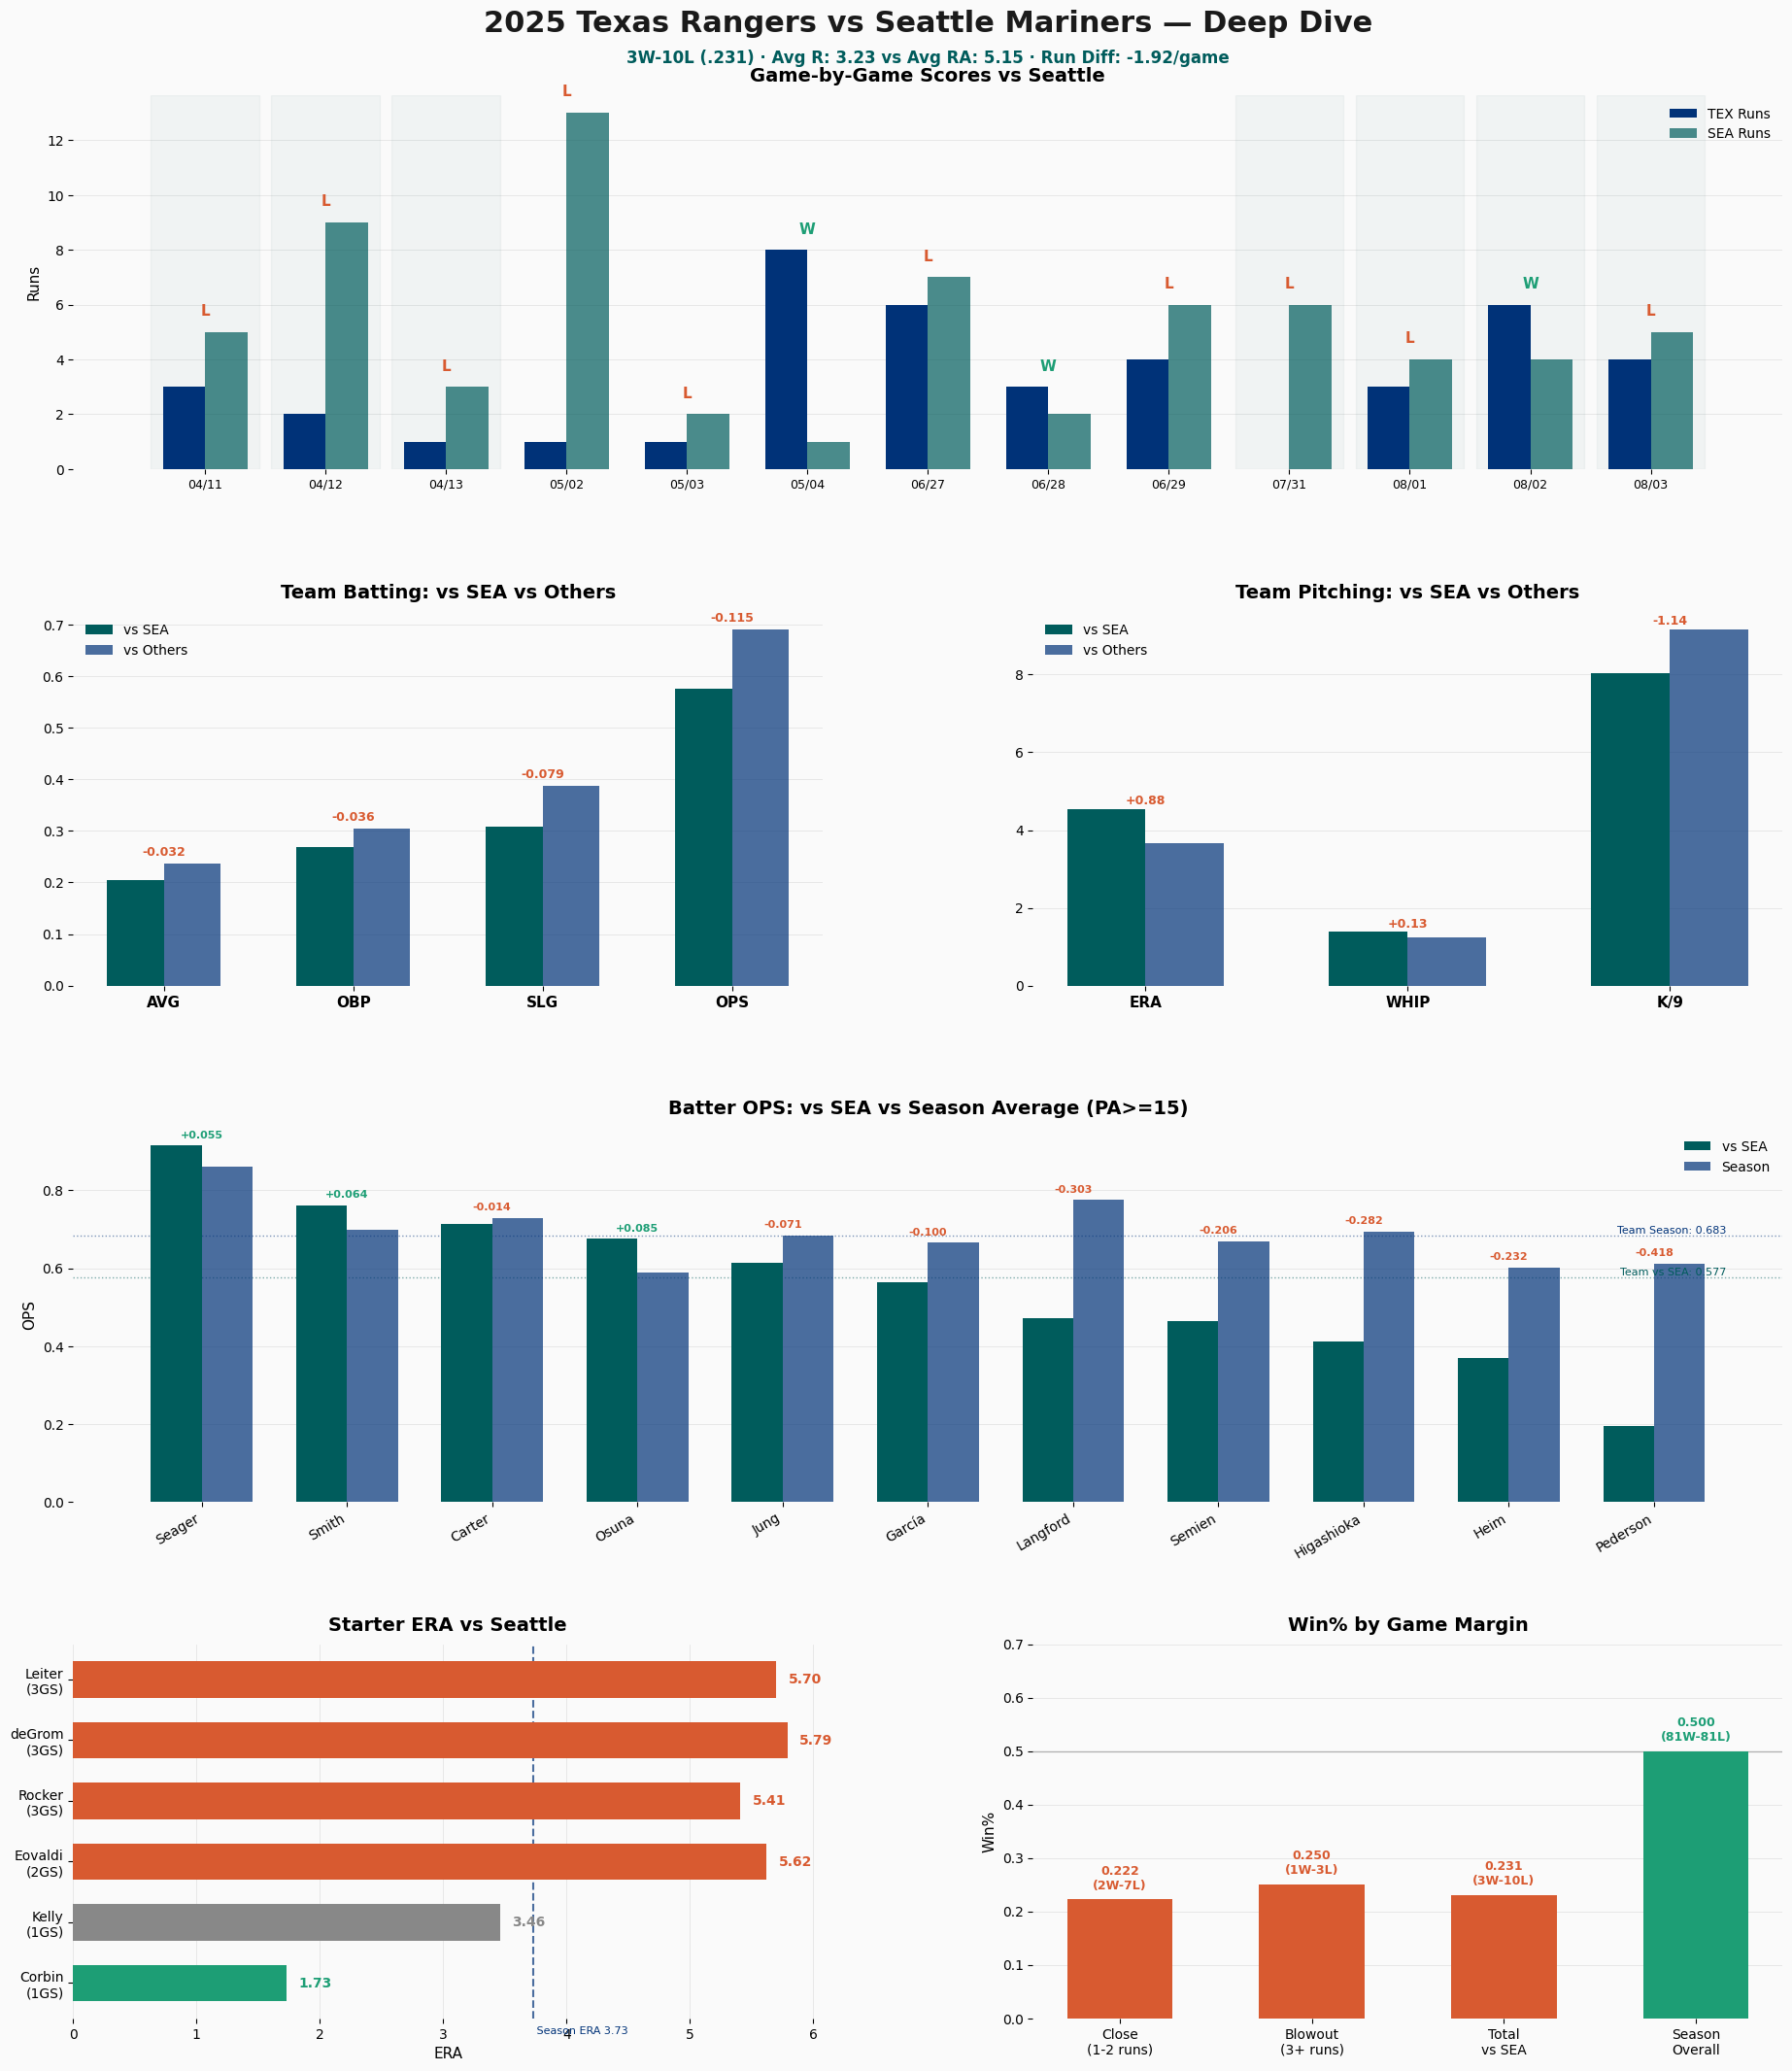

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
# ── 데이터 로드 (경로를 본인 환경에 맞게 수정) ──
game_log = pd.read_csv('./data/texas_2025_game_log.csv')
bat_log = pd.read_csv('./data/rangers_batter_gamelogs.csv')
pit_log = pd.read_csv('./data/rangers_pitcher_gamelogs.csv')
# 날짜 변환
game_log['Date'] = pd.to_datetime(game_log['Date'] + ', 2025', format='%A, %b %d, %Y')
bat_log['Date'] = pd.to_datetime(bat_log['Date'])
pit_log['Date'] = pd.to_datetime(pit_log['Date'])
# 숫자형 변환
bat_num = ['PA','AB','R','H','2B','3B','HR','RBI','BB','SO','SB','CS','HBP']
bat_log[bat_num] = bat_log[bat_num].apply(pd.to_numeric, errors='coerce')
pit_num = ['W','L','G','GS','SV','IP','H','R','ER','HR','BB','SO']
pit_log[pit_num] = pit_log[pit_num].apply(pd.to_numeric, errors='coerce')
# ── 텍사스 경기만 필터 ──
bat_tex = bat_log[(bat_log['Home Tm']=='Texas Rangers') | (bat_log['Away Tm']=='Texas Rangers')]
pit_tex = pit_log[(pit_log['Home Tm']=='Texas Rangers') | (pit_log['Away Tm']=='Texas Rangers')]
# ── 시애틀전 필터 ──
game_log['Result'] = game_log['W/L'].apply(lambda x: 'W' if x in ['W','W-wo'] else 'L')
sea_dates = game_log[game_log['Opp']=='SEA']['Date'].values
bat_sea = bat_tex[bat_tex['Date'].isin(sea_dates)]
pit_sea = pit_tex[pit_tex['Date'].isin(sea_dates)]
# ── 타격 스탯 계산 함수 ──
def calc_batting(df):
    ab, h, bb, hbp, pa = df['AB'].sum(), df['H'].sum(), df['BB'].sum(), df['HBP'].sum(), df['PA'].sum()
    hr, _2b, _3b = df['HR'].sum(), df['2B'].sum(), df['3B'].sum()
    tb = (h - _2b - _3b - hr) + _2b*2 + _3b*3 + hr*4
    avg = h/ab if ab else 0
    obp = (h+bb+hbp)/pa if pa else 0
    slg = tb/ab if ab else 0
    return round(avg,3), round(obp,3), round(slg,3), round(obp+slg,3)
# ── 타자별 시애틀 vs 시즌 OPS ──
def player_ops(df):
    g = df.groupby('name').agg(PA=('PA','sum'), AB=('AB','sum'), H=('H','sum'),
        HR=('HR','sum'), BB=('BB','sum'), HBP=('HBP','sum'),
        _2B=('2B','sum'), _3B=('3B','sum')).reset_index()
    g['AVG'] = (g['H']/g['AB']).round(3)
    g['OBP'] = ((g['H']+g['BB']+g['HBP'])/g['PA']).round(3)
    tb = (g['H']-g['_2B']-g['_3B']-g['HR']) + g['_2B']*2 + g['_3B']*3 + g['HR']*4
    g['SLG'] = (tb/g['AB']).round(3)
    g['OPS'] = (g['OBP']+g['SLG']).round(3)
    return g
p_sea = player_ops(bat_sea)
p_all = player_ops(bat_tex)
pm = p_sea[p_sea['PA']>=15].merge(p_all[['name','OPS']], on='name', suffixes=('_sea','_all'))
pm['OPS_diff'] = (pm['OPS_sea'] - pm['OPS_all']).round(3)
pm = pm.sort_values('OPS_sea', ascending=False)
# ── 팀 타격/투수 스탯 ──
sea_bat = calc_batting(bat_sea)
oth_bat = calc_batting(bat_tex[~bat_tex['Date'].isin(sea_dates)])
def calc_pitching(df):
    ip, er, h, bb, so = df['IP'].sum(), df['ER'].sum(), df['H'].sum(), df['BB'].sum(), df['SO'].sum()
    era = er*9/ip if ip else 0
    whip = (h+bb)/ip if ip else 0
    k9 = so*9/ip if ip else 0
    return round(era,2), round(whip,2), round(k9,2)
sea_pit = calc_pitching(pit_sea)
oth_pit = calc_pitching(pit_tex[~pit_tex['Date'].isin(sea_dates)])
# ── 선발투수별 ERA ──
st = pit_sea[pit_sea['GS']>0].groupby('name').agg(
    GS=('GS','sum'), IP=('IP','sum'), ER=('ER','sum')).reset_index()
st['ERA'] = (st['ER']*9/st['IP']).round(2)
st = st.sort_values('GS', ascending=False)
# ── 경기별 데이터 ──
sea_g = game_log[game_log['Opp']=='SEA'].copy()
# ═══════════════════════════════════════════
# 시각화 시작
# ═══════════════════════════════════════════
bg = '#FAFAFA'
tex_blue = '#003278'
sea_teal = '#005C5C'
win_g = '#1D9E75'
loss_r = '#D85A30'
gray = '#888888'
fig = plt.figure(figsize=(20, 22), facecolor=bg)
gs = gridspec.GridSpec(4, 2, hspace=0.38, wspace=0.28,
                       left=0.06, right=0.94, top=0.93, bottom=0.03)
fig.suptitle('2025 Texas Rangers vs Seattle Mariners — Deep Dive',
             fontsize=22, fontweight='bold', y=0.97, color='#1a1a1a')
fig.text(0.5, 0.945,
         f'3W-10L (.231) · Avg R: {sea_g["R"].mean():.2f} vs Avg RA: {sea_g["RA"].mean():.2f} '
         f'· Run Diff: {(sea_g["R"]-sea_g["RA"]).mean():+.2f}/game',
         ha='center', fontsize=12, color=sea_teal, fontweight='bold')
# 공통 스타일 함수
def style_ax(ax):
    ax.set_facecolor(bg)
    ax.grid(axis='y', color='#E0E0E0', linewidth=0.5)
    ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_visible(False)
# ─── 1. 경기별 득실점 타임라인 ───
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1)
dates_str = sea_g['Date'].dt.strftime('%m/%d').values
runs = sea_g['R'].values
ra = sea_g['RA'].values
results = sea_g['Result'].values
home_away = sea_g['Home_Away'].values
x = np.arange(len(dates_str))
w = 0.35
ax1.bar(x - w/2, runs, w, color=tex_blue, label='TEX Runs', zorder=3)
ax1.bar(x + w/2, ra, w, color=sea_teal, alpha=0.7, label='SEA Runs', zorder=3)
for i, res in enumerate(results):
    color = win_g if res == 'W' else loss_r
    ax1.text(i, max(runs[i], ra[i]) + 0.6, res, ha='center', fontsize=11,
             fontweight='bold', color=color)
# 홈/원정 구간 표시
for i, ha_val in enumerate(home_away):
    if ha_val == '@':
        ax1.axvspan(i-0.45, i+0.45, alpha=0.04, color=sea_teal, zorder=1)
ax1.set_xticks(x)
ax1.set_xticklabels(dates_str, fontsize=9)
ax1.set_ylabel('Runs', fontsize=11)
ax1.set_title('Game-by-Game Scores vs Seattle', fontsize=14, fontweight='bold', pad=10)
ax1.legend(fontsize=10, frameon=False, loc='upper right')
# ─── 2. 팀 타격 비교 ───
ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2)
cats = ['AVG', 'OBP', 'SLG', 'OPS']
sea_vals = list(sea_bat)
oth_vals = list(oth_bat)
x2 = np.arange(len(cats))
w2 = 0.3
ax2.bar(x2 - w2/2, sea_vals, w2, color=sea_teal, label='vs SEA', zorder=3)
ax2.bar(x2 + w2/2, oth_vals, w2, color=tex_blue, alpha=0.7, label='vs Others', zorder=3)
for i in range(len(cats)):
    diff = sea_vals[i] - oth_vals[i]
    ax2.text(i, max(sea_vals[i], oth_vals[i]) + 0.015, f'{diff:+.3f}',
             ha='center', fontsize=9, fontweight='bold', color=loss_r)
ax2.set_xticks(x2)
ax2.set_xticklabels(cats, fontsize=11, fontweight='bold')
ax2.set_title('Team Batting: vs SEA vs Others', fontsize=14, fontweight='bold', pad=10)
ax2.legend(fontsize=10, frameon=False)
# ─── 3. 팀 투구 비교 ───
ax3 = fig.add_subplot(gs[1, 1])
style_ax(ax3)
pit_cats = ['ERA', 'WHIP', 'K/9']
pit_sea_v = list(sea_pit)
pit_oth_v = list(oth_pit)
x3 = np.arange(len(pit_cats))
ax3.bar(x3 - w2/2, pit_sea_v, w2, color=sea_teal, label='vs SEA', zorder=3)
ax3.bar(x3 + w2/2, pit_oth_v, w2, color=tex_blue, alpha=0.7, label='vs Others', zorder=3)
for i in range(len(pit_cats)):
    diff = pit_sea_v[i] - pit_oth_v[i]
    worse = (diff > 0 and pit_cats[i] != 'K/9') or (diff < 0 and pit_cats[i] == 'K/9')
    color = loss_r if worse else win_g
    ax3.text(i, max(pit_sea_v[i], pit_oth_v[i]) + 0.12, f'{diff:+.2f}',
             ha='center', fontsize=9, fontweight='bold', color=color)
ax3.set_xticks(x3)
ax3.set_xticklabels(pit_cats, fontsize=11, fontweight='bold')
ax3.set_title('Team Pitching: vs SEA vs Others', fontsize=14, fontweight='bold', pad=10)
ax3.legend(fontsize=10, frameon=False)
# ─── 4. 타자별 OPS 비교 ───
ax4 = fig.add_subplot(gs[2, :])
style_ax(ax4)
names = pm['name'].str.split().str[-1].values  # 성만 표시
ops_sea_v = pm['OPS_sea'].values
ops_all_v = pm['OPS_all'].values
ops_diff = pm['OPS_diff'].values
x4 = np.arange(len(names))
w4 = 0.35
ax4.bar(x4 - w4/2, ops_sea_v, w4, color=sea_teal, label='vs SEA', zorder=3)
ax4.bar(x4 + w4/2, ops_all_v, w4, color=tex_blue, alpha=0.7, label='Season', zorder=3)
for i in range(len(names)):
    color = win_g if ops_diff[i] > 0 else loss_r
    ax4.text(i, max(ops_sea_v[i], ops_all_v[i]) + 0.02, f'{ops_diff[i]:+.03f}',
             ha='center', fontsize=8, fontweight='bold', color=color)
team_ops_sea = sea_bat[3]
team_ops_all = calc_batting(bat_tex)[3]
ax4.axhline(y=team_ops_sea, color=sea_teal, linewidth=1, linestyle=':', alpha=0.5)
ax4.text(len(names)-0.5, team_ops_sea+0.006, f'Team vs SEA: {team_ops_sea}', fontsize=8, color=sea_teal, ha='right')
ax4.axhline(y=team_ops_all, color=tex_blue, linewidth=1, linestyle=':', alpha=0.5)
ax4.text(len(names)-0.5, team_ops_all+0.006, f'Team Season: {team_ops_all}', fontsize=8, color=tex_blue, ha='right')
ax4.set_xticks(x4)
ax4.set_xticklabels(names, fontsize=10, rotation=30, ha='right')
ax4.set_ylabel('OPS', fontsize=11)
ax4.set_title('Batter OPS: vs SEA vs Season Average (PA>=15)', fontsize=14, fontweight='bold', pad=10)
ax4.legend(fontsize=10, frameon=False, loc='upper right')
# ─── 5. 선발투수 ERA vs SEA ───
ax5 = fig.add_subplot(gs[3, 0])
ax5.set_facecolor(bg)
ax5.grid(axis='x', color='#E0E0E0', linewidth=0.5)
ax5.set_axisbelow(True)
for s in ax5.spines.values(): s.set_visible(False)
sp_labels = [f"{r['name'].split()[-1]}\n({int(r['GS'])}GS)" for _, r in st.iterrows()]
sp_era = st['ERA'].values
colors5 = [loss_r if e > 4.0 else (gray if e > 3.0 else win_g) for e in sp_era]
season_era = calc_pitching(pit_tex)[0]
ax5.barh(np.arange(len(sp_labels)), sp_era, color=colors5, height=0.6, zorder=3)
ax5.axvline(x=season_era, color=tex_blue, linewidth=1.5, linestyle='--', alpha=0.7)
ax5.text(season_era, len(sp_labels)-0.3, f' Season ERA {season_era}', fontsize=8, color=tex_blue, va='top')
for i, v in enumerate(sp_era):
    ax5.text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=10, fontweight='bold', color=colors5[i])
ax5.set_yticks(np.arange(len(sp_labels)))
ax5.set_yticklabels(sp_labels, fontsize=10)
ax5.set_xlabel('ERA', fontsize=11)
ax5.set_title('Starter ERA vs Seattle', fontsize=14, fontweight='bold', pad=10)
ax5.invert_yaxis()
# ─── 6. 접전 vs 대차 승률 ───
ax6 = fig.add_subplot(gs[3, 1])
style_ax(ax6)
sea_g_copy = sea_g.copy()
sea_g_copy['Margin'] = abs(sea_g_copy['R'] - sea_g_copy['RA'])
close = sea_g_copy[sea_g_copy['Margin'] <= 2]
blow = sea_g_copy[sea_g_copy['Margin'] > 2]
categories = ['Close\n(1-2 runs)', 'Blowout\n(3+ runs)', 'Total\nvs SEA', 'Season\nOverall']
wins = [(close['Result']=='W').sum(), (blow['Result']=='W').sum(),
        (sea_g['Result']=='W').sum(), (game_log['Result']=='W').sum()]
losses = [(close['Result']=='L').sum(), (blow['Result']=='L').sum(),
          (sea_g['Result']=='L').sum(), (game_log['Result']=='L').sum()]
win_pcts = [w/(w+l) if (w+l)>0 else 0 for w, l in zip(wins, losses)]
bar_colors = [loss_r if p < 0.4 else (gray if p < 0.5 else win_g) for p in win_pcts]
ax6.bar(np.arange(len(categories)), win_pcts, color=bar_colors, width=0.55, zorder=3)
ax6.axhline(y=0.5, color='#333', linewidth=1, linestyle='-', alpha=0.3)
for i, (p, w, l) in enumerate(zip(win_pcts, wins, losses)):
    ax6.text(i, p + 0.02, f'{p:.3f}\n({w}W-{l}L)', ha='center', fontsize=9,
             fontweight='bold', color=bar_colors[i])
ax6.set_xticks(np.arange(len(categories)))
ax6.set_xticklabels(categories, fontsize=10)
ax6.set_ylabel('Win%', fontsize=11)
ax6.set_ylim(0, 0.7)
ax6.set_title('Win% by Game Margin', fontsize=14, fontweight='bold', pad=10)
plt.savefig('tex_vs_sea_deep_dive.png', dpi=200, bbox_inches='tight', facecolor=bg)
plt.show()